# Punto 3 Duque & Becerra Consulting

## Imports y configuración

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.model_selection import train_test_split, KFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import ElasticNetCV, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.feature_selection import SelectFromModel


sns.set_theme(style="whitegrid")

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

SCORING_MAIN = "f1"

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

# Preprocessing & PCA
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Clustering
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN

# Evaluación
from sklearn.metrics import silhouette_score, silhouette_samples

# Dendrograma
from scipy.cluster.hierarchy import dendrogram, linkage

sns.set_theme(style="whitegrid")
print("Imports cargados correctamente.")

Imports cargados correctamente.


In [2]:

RANDOM_STATE = 1999
K_RANGE = range(2, 11)          # rango de k para K-Means y Aglomerativo
DBSCAN_EPS_RANGE = np.arange(0.3, 2.1, 0.1)
DBSCAN_MIN_SAMPLES_RANGE = [3, 5, 7, 10]
N_PCA_COMPONENTS = 2            # componentes para visualización
FIGSIZE_WIDE = (14, 5)
FIGSIZE_SQUARE = (8, 6)

## Limpieza 
Importamos la base y hacemos ajuste de variables categoricas, es decir volvemos binaria genero, y hacemos un ajuste de 0-1 para cada categoria, con el objetivo de cuando se tengan los clusters, saber como se comportan los consumidores, en la base no hay missings.

In [3]:
df = pd.read_csv("/Users/juanfelipe/Documents/Datos_Taller1/Punto3/segmentación.csv")
df.head()

,id,age,gender,income,spending_score,membership_years,purchase_frequency,preferred_category,last_purchase_amount
0,1,38,Female,99342,90,3,24,Groceries,113.53
1,2,21,Female,78852,60,2,42,Sports,41.93
2,3,60,Female,126573,30,2,28,Clothing,424.36
3,4,40,Other,47099,74,9,5,Home & Garden,991.93
4,5,65,Female,140621,21,3,25,Electronics,347.08


In [4]:
# add a binary column indicating if the gender is Female
df['Female'] = (df['gender'] == 'Female').astype(int)
df['Male'] = (df['gender'] == 'Male').astype(int)
df['Other'] = (df['gender'] == 'Other').astype(int)

df

,id,age,gender,income,spending_score,membership_years,purchase_frequency,preferred_category,last_purchase_amount,Female,Male,Other
0,1,38,Female,99342,90,3,24,Groceries,113.53,1,0,0
1,2,21,Female,78852,60,2,42,Sports,41.93,1,0,0
2,3,60,Female,126573,30,2,28,Clothing,424.36,1,0,0
3,4,40,Other,47099,74,9,5,Home & Garden,991.93,0,0,1
4,5,65,Female,140621,21,3,25,Electronics,347.08,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,57,Male,112170,57,6,1,Clothing,313.64,0,1,0
996,997,23,Other,65337,76,10,23,Groceries,632.83,0,0,1
997,998,23,Male,113097,40,5,42,Sports,75.09,0,1,0
998,999,22,Female,113695,63,7,44,Electronics,505.16,1,0,0


In [5]:
df['preferred_category'].unique()

<StringArray>
['Groceries', 'Sports', 'Clothing', 'Home & Garden', 'Electronics']
Length: 5, dtype: str

In [6]:
df['Groceries'] = (df['preferred_category'] == 'Groceries').astype(int)
df['Clothing'] = (df['preferred_category'] == 'Clothing').astype(int)
df['Electronics'] = (df['preferred_category'] == 'Electronics').astype(int)
df['Sports'] = (df['preferred_category'] == 'Sports').astype(int)
df['Home_&_Garden'] = (df['preferred_category'] == 'Home & Garden').astype(int)

In [7]:
COLUMNASCOMP= ["age","income","spending_score","membership_years","purchase_frequency","last_purchase_amount"]
META_COLS = ["gender","preferred_category"]

X = df[COLUMNASCOMP].copy()
meta = df[META_COLS].copy()

print(f"Features de segmentación: {COLUMNASCOMP}")
print(f"Shape X: {X.shape}")

# Validación
if X.isna().sum().sum() > 0:
    raise ValueError("Hay valores nulos en X.")
print("Sin valores nulos en features.")

Features de segmentación: ['age', 'income', 'spending_score', 'membership_years', 'purchase_frequency', 'last_purchase_amount']
Shape X: (1000, 6)
Sin valores nulos en features.


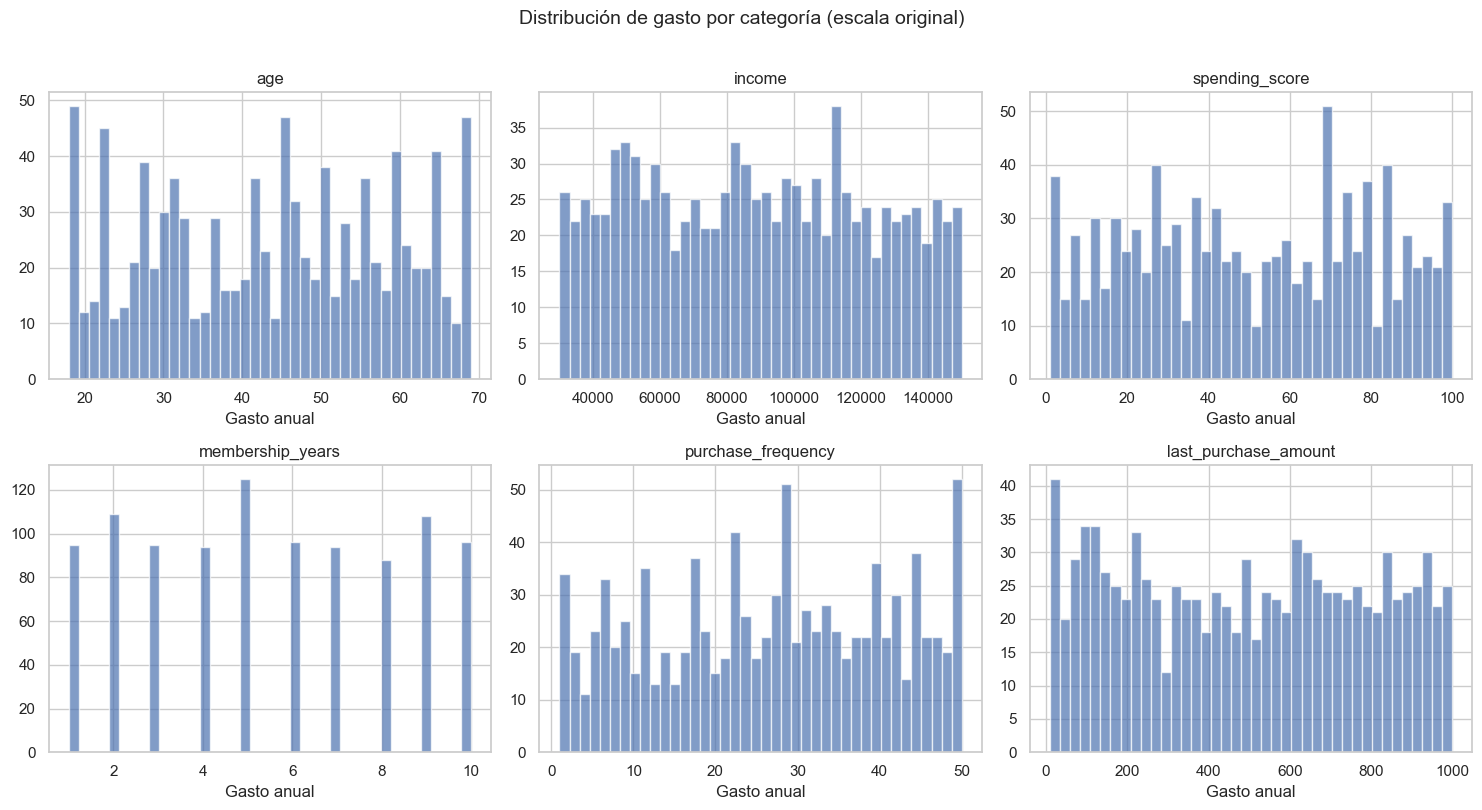

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), COLUMNASCOMP):
    ax.hist(X[col], bins=40, edgecolor="white", alpha=0.7)
    ax.set_title(col, fontsize=12)
    ax.set_xlabel("Gasto anual")
fig.suptitle("Distribución de gasto por categoría (escala original)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

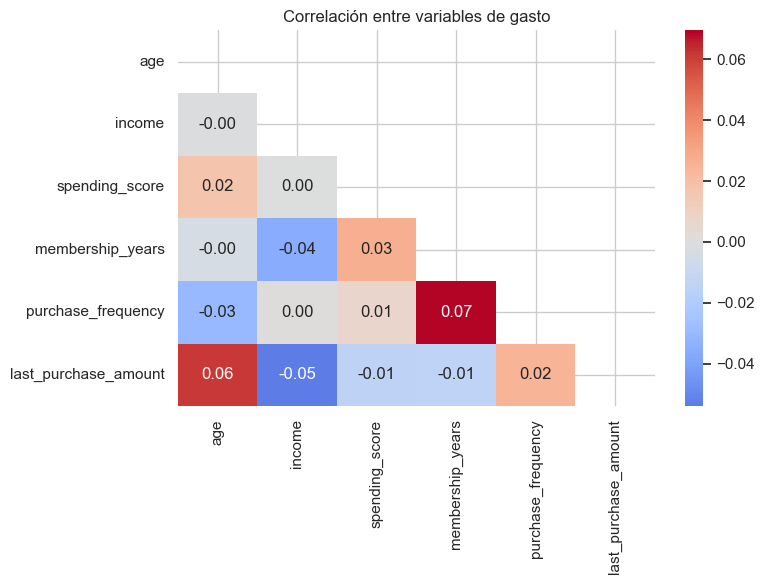

In [9]:
fig, ax = plt.subplots(figsize=(8, 6))
corr = X.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, 
            mask=mask,
            annot=True, 
            fmt=".2f", 
            cmap="coolwarm",
            center=0,
            ax=ax)
ax.set_title("Correlación entre variables de gasto")
plt.tight_layout()
plt.show()

In [10]:
X_log = np.log1p(X)

# Estandarización
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)
X_scaled = pd.DataFrame(X_scaled, columns=COLUMNASCOMP, index=X.index)

print("Estadísticas después de log + StandardScaler:")
display(X_scaled.describe().round(2))


# compare skewness antes y después
skew_before = X.skew().round(2)
skew_after = X_scaled.skew().round(2)
skew_df = pd.DataFrame({
    "Skewness Antes": skew_before,
    "Skewness Después": skew_after
})
print("\nSkewness antes y después de la transformación:")
display(skew_df)

Estadísticas después de log + StandardScaler:


,age,income,spending_score,membership_years,purchase_frequency,last_purchase_amount
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,0.00,0.00,0.00,0.00,-0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00
min,-2.14,-2.29,-3.45,-2.02,-3.23,-3.61
25%,-0.82,-0.78,-0.45,-0.69,-0.45,-0.52
50%,0.24,0.18,0.29,0.09,0.30,0.32
75%,0.87,0.82,0.76,0.86,0.77,0.76
max,1.38,1.41,1.08,1.25,1.10,1.06



Skewness antes y después de la transformación:


,Skewness Antes,Skewness Después
age,-0.05,-0.51
income,0.05,-0.51
spending_score,-0.02,-1.38
membership_years,0.03,-0.62
purchase_frequency,-0.08,-1.24
last_purchase_amount,0.02,-1.32


## PCA
Realizamos PCA para bajar la dimensionalidad, como vemos unicamente hay una distribucion de varianza parecida entre todas las variables, no teniendo que reducir la dimensionalidad, estando ya en un buen numero de dimensiones.

In [11]:
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_scaled)

var_exp = pca_full.explained_variance_ratio_
var_cum = np.cumsum(var_exp)

print("Varianza explicada por componente:")
for i, (v, vc) in enumerate(zip(var_exp, var_cum), 1):
    print(f"  PC{i}: {v:.4f}  (acumulada: {vc:.4f})")

Varianza explicada por componente:
  PC1: 0.1811  (acumulada: 0.1811)
  PC2: 0.1781  (acumulada: 0.3592)
  PC3: 0.1687  (acumulada: 0.5279)
  PC4: 0.1665  (acumulada: 0.6944)
  PC5: 0.1591  (acumulada: 0.8535)
  PC6: 0.1465  (acumulada: 1.0000)


In [12]:
var_exp

array([0.1810978 , 0.17810455, 0.16871041, 0.16650459, 0.15907105,
       0.1465116 ])

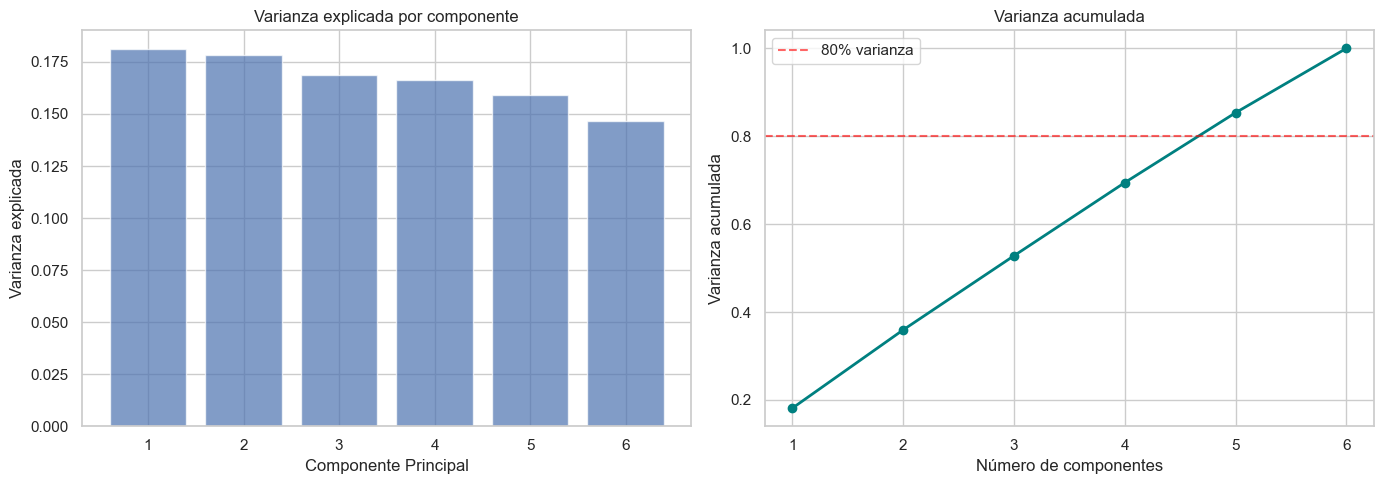

In [13]:
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_WIDE)

# Varianza individual
axes[0].bar(range(1, len(var_exp) + 1), var_exp, alpha=0.7, edgecolor="white")
axes[0].set_xlabel("Componente Principal")
axes[0].set_ylabel("Varianza explicada")
axes[0].set_title("Varianza explicada por componente")
axes[0].set_xticks(range(1, len(var_exp) + 1))

# Varianza acumulada
axes[1].plot(range(1, len(var_cum) + 1), var_cum, "o-", color="teal", linewidth=2)
axes[1].axhline(y=0.80, color="red", linestyle="--", alpha=0.6, label="80% varianza")
axes[1].set_xlabel("Número de componentes")
axes[1].set_ylabel("Varianza acumulada")
axes[1].set_title("Varianza acumulada")
axes[1].set_xticks(range(1, len(var_cum) + 1))
axes[1].legend()

plt.tight_layout()
plt.show()

In [14]:
pca_2d = PCA(n_components=N_PCA_COMPONENTS, random_state=RANDOM_STATE)
X_pca = pca_2d.fit_transform(X_scaled)

print(f"Varianza explicada por PC1 + PC2: {pca_2d.explained_variance_ratio_.sum():.4f}")
print(f"Shape proyección: {X_pca.shape}")

Varianza explicada por PC1 + PC2: 0.3592
Shape proyección: (1000, 2)


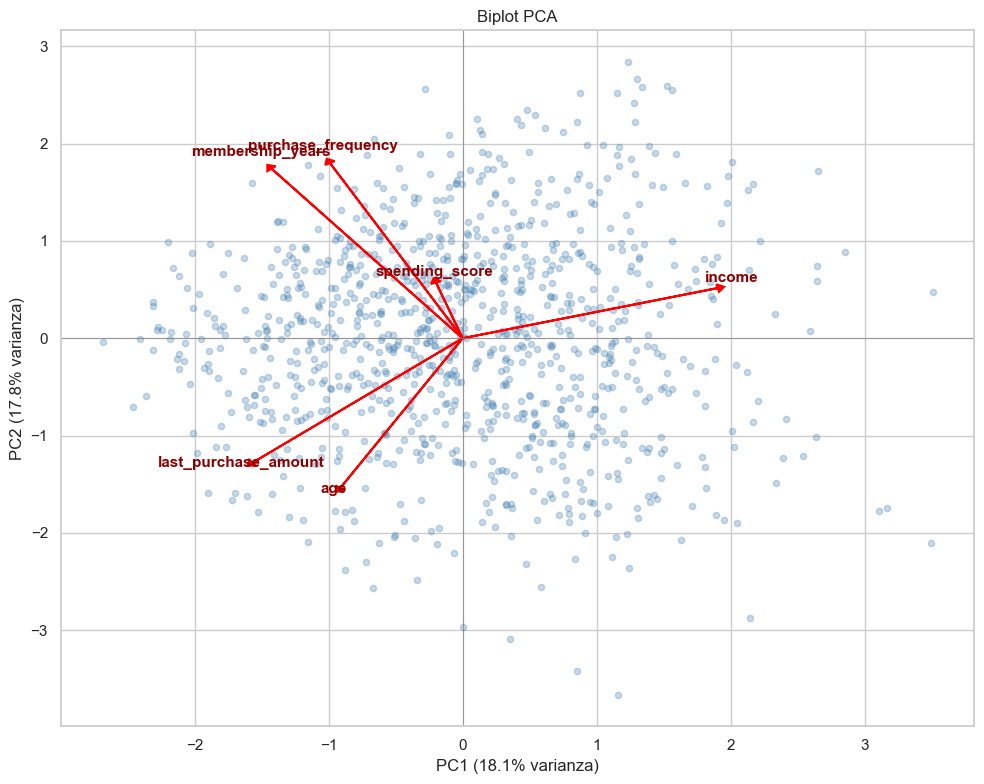

In [15]:
def biplot(score, coeff, labels, ax=None):
    """Genera un biplot de PCA: scores (puntos) + loadings (flechas)."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 8))

    # Scatter de observaciones
    ax.scatter(x = score[:, 0], y = score[:, 1], 
               alpha=0.3, s=20, c="steelblue")

    # Flechas de loadings
    scale = np.abs(score).max(axis=0)  # escalar flechas 
    for i, label in enumerate(labels):
        ax.arrow(
            0, 0,
            coeff[i, 0] * scale[0] * 0.9,
            coeff[i, 1] * scale[1] * 0.9,
            head_width=0.08, head_length=0.05,
            fc="red", ec="red", linewidth=1.5
        )
        ax.text(
            coeff[i, 0] * scale[0] * 0.95,
            coeff[i, 1] * scale[1] * 0.95,
            label, fontsize=11, color="darkred", fontweight="bold",
            ha="center", va="bottom"
        )

    ax.set_xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} varianza)")
    ax.set_ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} varianza)")
    ax.set_title("Biplot PCA")
    ax.axhline(0, color="grey", linewidth=0.5)
    ax.axvline(0, color="grey", linewidth=0.5)
    return ax


fig, ax = plt.subplots(figsize=(10, 8))
biplot(X_pca, pca_2d.components_.T,COLUMNASCOMP, ax=ax)
plt.tight_layout()
plt.show()

## Evaluacion con K-Means, maximizando Sihloette
Se ve la clusterización y las mediciones sacadas despues de ello.

In [16]:
def evaluate_clustering(X, labels, method_name):
    """Calcula métricas de clustering y retorna un dict resumen."""
    n_clusters = len(set(labels) - {-1})  # excluir ruido (-1)
    n_noise = (labels == -1).sum()

    # Silhouette solo si hay al menos 2 clusters y no todo es ruido
    mask = labels != -1
    if n_clusters >= 2 and mask.sum() > n_clusters:
        sil = silhouette_score(X[mask], labels[mask])
    else:
        sil = np.nan

    return {
        "method": method_name,
        "n_clusters": n_clusters,
        "n_noise": n_noise,
        "silhouette": round(sil, 4) if not np.isnan(sil) else np.nan,
    }

In [17]:
inertias = []
sil_scores_km = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    labels_k = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores_km.append(silhouette_score(X_scaled, labels_k))

best_k_km = list(K_RANGE)[np.argmax(sil_scores_km)]
print(f"Mejor k (K-Means) por Silhouette: {best_k_km} (score = {max(sil_scores_km):.4f})")

Mejor k (K-Means) por Silhouette: 7 (score = 0.1745)


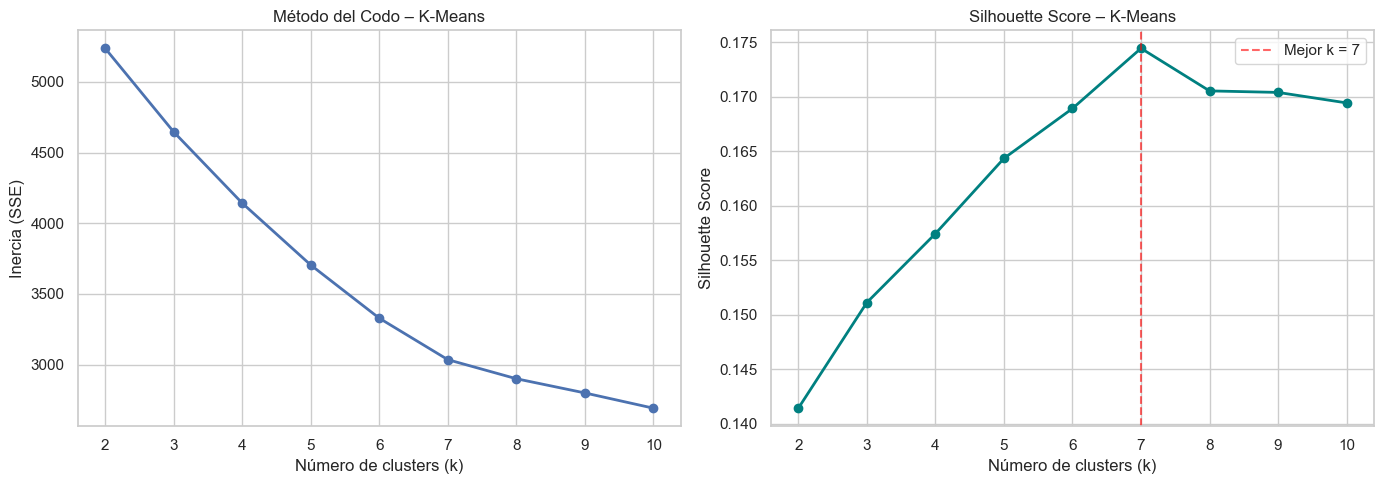

In [18]:
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_WIDE)

# Método del codo
axes[0].plot(list(K_RANGE), inertias, "o-", linewidth=2)
axes[0].set_xlabel("Número de clusters (k)")
axes[0].set_ylabel("Inercia (SSE)")
axes[0].set_title("Método del Codo – K-Means")

# Silhouette vs k
axes[1].plot(list(K_RANGE), sil_scores_km, "o-", linewidth=2, color="teal")
axes[1].axvline(x=best_k_km, color="red", linestyle="--", alpha=0.6, label=f"Mejor k = {best_k_km}")
axes[1].set_xlabel("Número de clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score – K-Means")
axes[1].legend()

plt.tight_layout()
plt.show()

In [19]:
km_final = KMeans(n_clusters=best_k_km, n_init=10, random_state=RANDOM_STATE)
labels_km = km_final.fit_predict(X_scaled)

res_km = evaluate_clustering(
    X_scaled.values, 
    labels_km, 
    f"K-Means (k={best_k_km})")
print(res_km)

{'method': 'K-Means (k=7)', 'n_clusters': 7, 'n_noise': np.int64(0), 'silhouette': 0.1745}


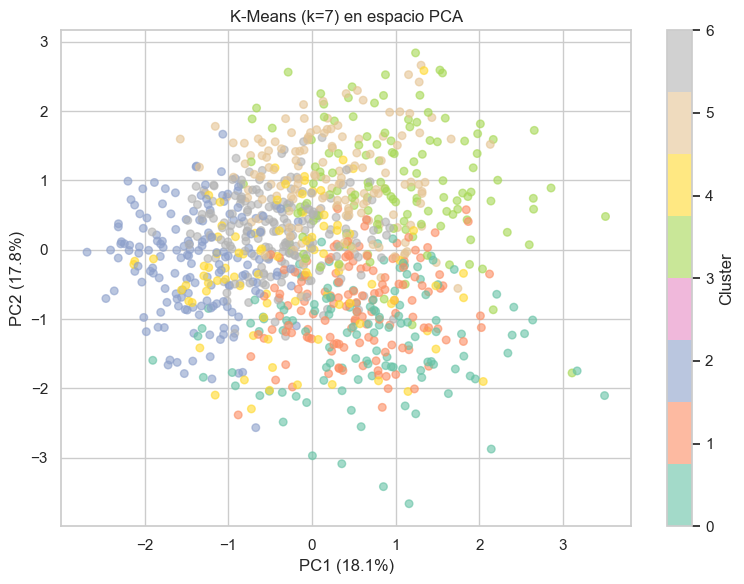

In [20]:
fig, ax = plt.subplots(figsize=FIGSIZE_SQUARE)
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_km, cmap="Set2", alpha=0.6, s=30)
ax.set_xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})")
ax.set_title(f"K-Means (k={best_k_km}) en espacio PCA")
plt.colorbar(scatter, ax=ax, label="Cluster")
plt.tight_layout()
plt.show()

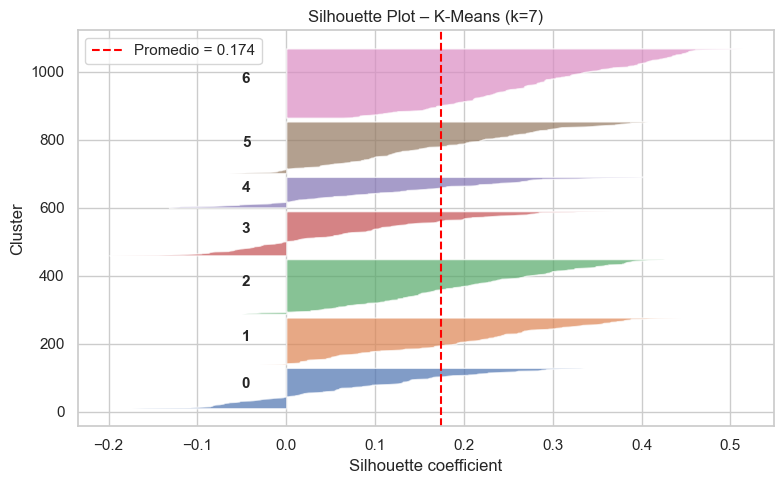

In [21]:
def plot_silhouette(X, labels, title):
    """Genera un silhouette plot por cluster."""
    mask = labels != -1
    X_clean = X[mask]
    labels_clean = labels[mask]

    sil_avg = silhouette_score(X_clean, labels_clean)
    sample_sil = silhouette_samples(X_clean, labels_clean)
    n_clusters = len(set(labels_clean))

    fig, ax = plt.subplots(figsize=(8, 5))
    y_lower = 10

    for i in sorted(set(labels_clean)):
        cluster_sil = np.sort(sample_sil[labels_clean == i])
        size_i = cluster_sil.shape[0]
        y_upper = y_lower + size_i

        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil, alpha=0.7)
        ax.text(-0.05, y_lower + 0.5 * size_i, str(i), fontsize=11, fontweight="bold")
        y_lower = y_upper + 10

    ax.axvline(x=sil_avg, color="red", linestyle="--", linewidth=1.5,
               label=f"Promedio = {sil_avg:.3f}")
    ax.set_xlabel("Silhouette coefficient")
    ax.set_ylabel("Cluster")
    ax.set_title(title)
    ax.legend(loc="best")
    plt.tight_layout()
    plt.show()

plot_silhouette(X_scaled.values, labels_km, f"Silhouette Plot – K-Means (k={best_k_km})")

## Evaluamos Clusterizacion jerarquica
Esta es la elegida, dado que estamos buscando unos clusters mas grandes que no fueron conseguidos con los otros metodos, a pesar de tener un sihloette más bajo, para el objetivo de consultoria, este fue el mejor resultado. Igual se maximiza el Silhoette en 4 clusters, y se evalua la composicion de estos para la recomendación final.

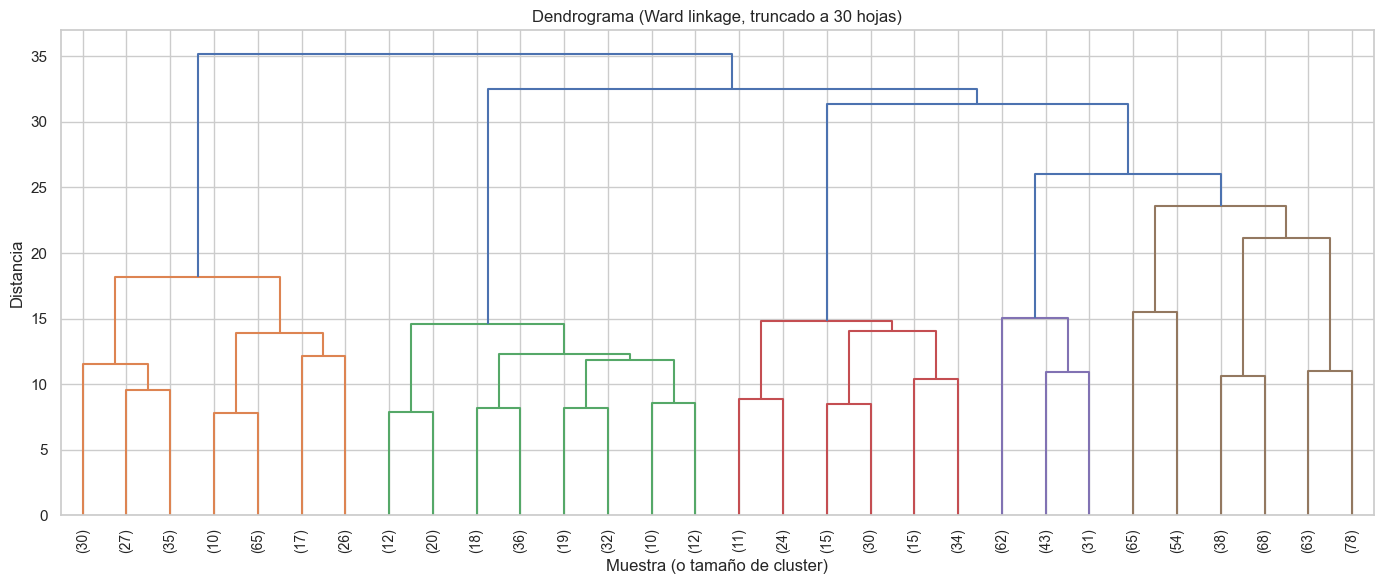

In [22]:
Z = linkage(X_scaled, method="ward")

fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(
    Z,
    truncate_mode="lastp", p=30,
    leaf_rotation=90, leaf_font_size=10,
    ax=ax,
)
ax.set_title("Dendrograma (Ward linkage, truncado a 30 hojas)")
ax.set_xlabel("Muestra (o tamaño de cluster)")
ax.set_ylabel("Distancia")
plt.tight_layout()
plt.show()

In [23]:
sil_scores_agg = []

for k in K_RANGE:
    agg = AgglomerativeClustering(n_clusters=k, linkage="ward")
    labels_agg_k = agg.fit_predict(X_scaled)
    sil_scores_agg.append(silhouette_score(X_scaled, labels_agg_k))

best_k_agg = list(K_RANGE)[np.argmax(sil_scores_agg)]
print(f"Mejor k (Aglomerativo) por Silhouette: {best_k_agg} (score = {max(sil_scores_agg):.4f})")

Mejor k (Aglomerativo) por Silhouette: 4 (score = 0.1391)


In [24]:
agg_final = AgglomerativeClustering(n_clusters=4, linkage="ward")
labels_agg = agg_final.fit_predict(X_scaled)

In [25]:
df['cluster'] = labels_agg
df

,id,age,gender,income,spending_score,membership_years,purchase_frequency,preferred_category,last_purchase_amount,Female,Male,Other,Groceries,Clothing,Electronics,Sports,Home_&_Garden,cluster
0,1,38,Female,99342,90,3,24,Groceries,113.53,1,0,0,1,0,0,0,0,2
1,2,21,Female,78852,60,2,42,Sports,41.93,1,0,0,0,0,0,1,0,2
2,3,60,Female,126573,30,2,28,Clothing,424.36,1,0,0,0,1,0,0,0,0
3,4,40,Other,47099,74,9,5,Home & Garden,991.93,0,0,1,0,0,0,0,1,1
4,5,65,Female,140621,21,3,25,Electronics,347.08,1,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,57,Male,112170,57,6,1,Clothing,313.64,0,1,0,0,1,0,0,0,1
996,997,23,Other,65337,76,10,23,Groceries,632.83,0,0,1,1,0,0,0,0,0
997,998,23,Male,113097,40,5,42,Sports,75.09,0,1,0,0,0,0,1,0,2
998,999,22,Female,113695,63,7,44,Electronics,505.16,1,0,0,0,0,1,0,0,0


In [26]:
df = df.drop(columns=META_COLS)

In [27]:
promedios = df.groupby('cluster').mean()
promedios['n_observaciones'] = df.groupby('cluster').size()
print(promedios)

                 id        age        income  spending_score  \
cluster                                                        
0        504.191235  43.486056  89334.061753       57.077689   
1        519.604762  44.085714  89686.295238       54.095238   
2        440.943396  41.836478  97959.094340       58.251572   
3        528.441860  46.844961  71670.410853       10.930233   

         membership_years  purchase_frequency  last_purchase_amount    Female  \
cluster                                                                         
0                5.334661           32.268924            602.564622  0.298805   
1                5.285714            7.514286            506.084857  0.342857   
2                5.742138           32.276730            102.768931  0.339623   
3                5.953488           28.581395            521.264729  0.310078   

             Male     Other  Groceries  Clothing  Electronics    Sports  \
cluster                                              

In [28]:
sil_scores_agg

[0.13021591612274352,
 0.12785215925114313,
 0.13908999577529668,
 0.11867538296932686,
 0.10343587164189702,
 0.08494361208760956,
 0.0948634420367768,
 0.0841317260893003,
 0.08347918206226886]

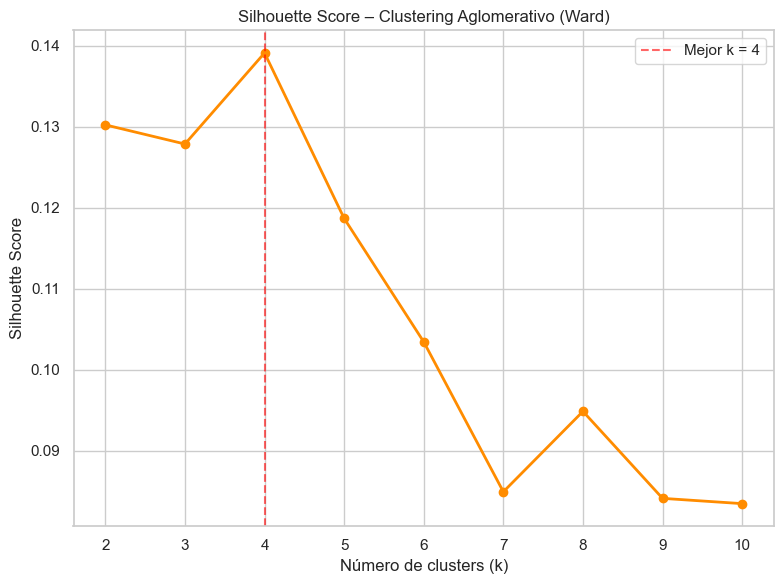

In [29]:
fig, ax = plt.subplots(figsize=FIGSIZE_SQUARE)
ax.plot(list(K_RANGE), sil_scores_agg, "o-", linewidth=2, color="darkorange")
ax.axvline(x=best_k_agg, color="red", linestyle="--", alpha=0.6, label=f"Mejor k = {best_k_agg}")
ax.set_xlabel("Número de clusters (k)")
ax.set_ylabel("Silhouette Score")
ax.set_title("Silhouette Score – Clustering Aglomerativo (Ward)")
ax.legend()
plt.tight_layout()
plt.show()

In [30]:
agg_final = AgglomerativeClustering(n_clusters=best_k_agg, linkage="ward")
labels_agg = agg_final.fit_predict(X_scaled)

res_agg = evaluate_clustering(X_scaled.values, labels_agg, f"Aglomerativo (k={best_k_agg})")
print(res_agg)

{'method': 'Aglomerativo (k=4)', 'n_clusters': 4, 'n_noise': np.int64(0), 'silhouette': 0.1391}


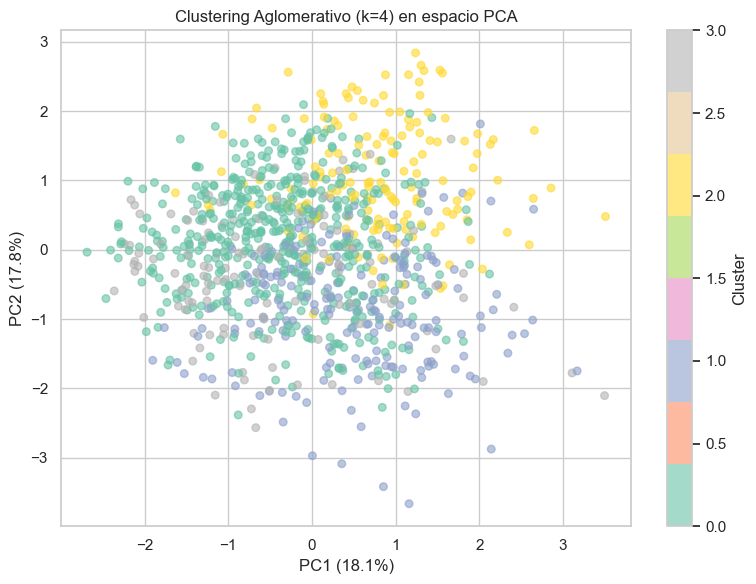

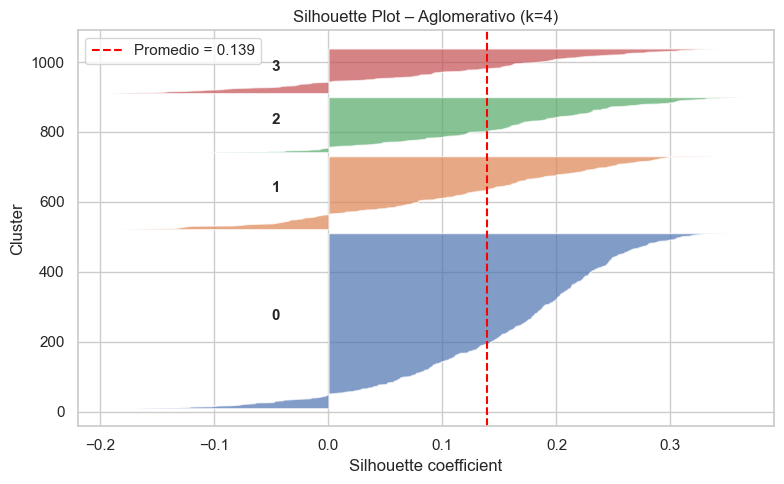

In [31]:
fig, ax = plt.subplots(figsize=FIGSIZE_SQUARE)
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_agg, cmap="Set2", alpha=0.6, s=30)
ax.set_xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})")
ax.set_title(f"Clustering Aglomerativo (k={best_k_agg}) en espacio PCA")
plt.colorbar(scatter, ax=ax, label="Cluster")
plt.tight_layout()
plt.show()

plot_silhouette(X_scaled.values, labels_agg, f"Silhouette Plot – Aglomerativo (k={best_k_agg})")

## Evaluamos DBSCAN
A pesar de que muestra el silhoette mas alto, carece de relevancia para la recomendacion, ya que en el que maximiza el silhoette, son 3 clusters, pero este cuenta con mucho ruido, y para asegurarnos que el ruido no sea alto, k=2, lo que no nos satisface para la recomendacion al cliente.

In [32]:
DBSCAN_EPS_RANGE

array([0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. , 1.1, 1.2, 1.3, 1.4, 1.5,
       1.6, 1.7, 1.8, 1.9, 2. ])

In [33]:
DBSCAN_MIN_SAMPLES_RANGE

[3, 5, 7, 10]

In [34]:
dbscan_results = []

for eps in DBSCAN_EPS_RANGE:
    for min_samples in DBSCAN_MIN_SAMPLES_RANGE:
        db = DBSCAN(eps=eps, min_samples=min_samples)
        labels_db = db.fit_predict(X_scaled)

        n_clusters = len(set(labels_db) - {-1})
        n_noise = (labels_db == -1).sum()
        noise_pct = n_noise / len(labels_db) * 100

        # Silhouette solo si hay >=2 clusters y suficientes puntos no-ruido
        mask = labels_db != -1
        if n_clusters >= 2 and mask.sum() > n_clusters:
            sil = silhouette_score(X_scaled.values[mask], labels_db[mask])
        else:
            sil = np.nan

        dbscan_results.append({
            "eps": round(eps, 2),
            "min_samples": min_samples,
            "n_clusters": n_clusters,
            "n_noise": n_noise,
            "noise_pct": round(noise_pct, 1),
            "silhouette": round(sil, 4) if not np.isnan(sil) else np.nan,
        })

df_dbscan = pd.DataFrame(dbscan_results)
print("Top 10 configuraciones DBSCAN por Silhouette:")
display(df_dbscan.dropna(subset=["silhouette"]).sort_values("silhouette", ascending=False).head(10))

Top 10 configuraciones DBSCAN por Silhouette:


,eps,min_samples,n_clusters,n_noise,noise_pct,silhouette
13,0.6,5,3,972,97.2,0.4931
8,0.5,3,13,953,95.3,0.4717
12,0.6,3,30,855,85.5,0.3610
18,0.7,7,3,952,95.2,0.3503
22,0.8,7,2,829,82.9,0.3366
53,1.6,5,2,29,2.9,0.2677
52,1.6,3,2,14,1.4,0.2639
23,0.8,10,6,897,89.7,0.2574
49,1.5,5,2,56,5.6,0.2568
48,1.5,3,2,32,3.2,0.2567


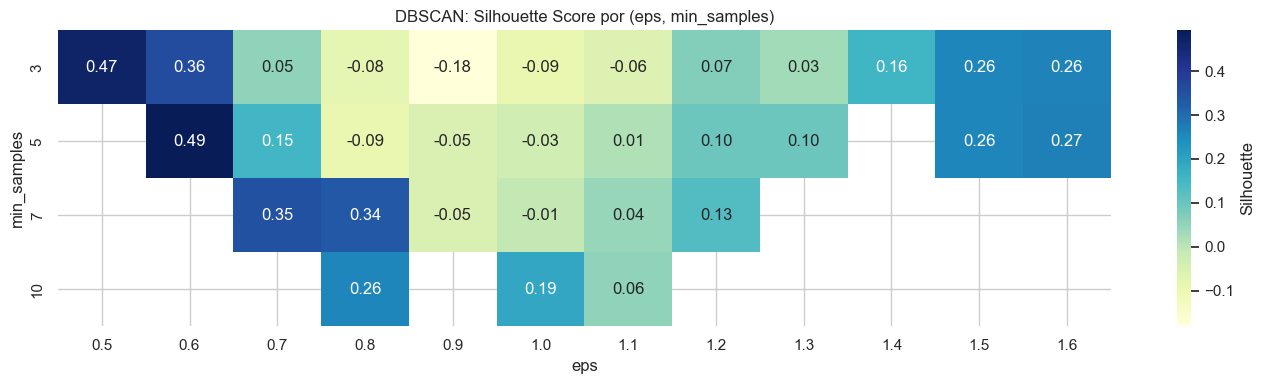

In [35]:
pivot = df_dbscan.pivot_table(index="min_samples", columns="eps", values="silhouette")

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="YlGnBu", ax=ax, cbar_kws={"label": "Silhouette"})
ax.set_title("DBSCAN: Silhouette Score por (eps, min_samples)")
ax.set_xlabel("eps")
ax.set_ylabel("min_samples")
plt.tight_layout()
plt.show()

In [36]:
df_valid = df_dbscan.dropna(subset=["silhouette"]).query("noise_pct < 30 and n_clusters >= 2")

if len(df_valid) > 0:
    best_db = df_valid.sort_values("silhouette", ascending=False).iloc[0]
    best_eps = best_db["eps"]
    best_min_samples = int(best_db["min_samples"])
    print(f"Mejor DBSCAN: eps={best_eps}, min_samples={best_min_samples}")
    print(f"  Clusters: {int(best_db['n_clusters'])}, Ruido: {best_db['noise_pct']}%, Silhouette: {best_db['silhouette']}")
else:
    # Fallback: relajar restricción de ruido
    df_valid = df_dbscan.dropna(subset=["silhouette"]).query("n_clusters >= 2")
    best_db = df_valid.sort_values("silhouette", ascending=False).iloc[0]
    best_eps = best_db["eps"]
    best_min_samples = int(best_db["min_samples"])
    print(f"Mejor DBSCAN (sin filtro de ruido): eps={best_eps}, min_samples={best_min_samples}")
    print(f"  Clusters: {int(best_db['n_clusters'])}, Ruido: {best_db['noise_pct']}%, Silhouette: {best_db['silhouette']}")

Mejor DBSCAN: eps=1.6, min_samples=5
  Clusters: 2, Ruido: 2.9%, Silhouette: 0.2677


In [37]:
db_final = DBSCAN(eps=best_eps, min_samples=best_min_samples)
labels_db = db_final.fit_predict(X_scaled)

res_db = evaluate_clustering(X_scaled.values, labels_db, f"DBSCAN (eps={best_eps}, ms={best_min_samples})")
print(res_db)

{'method': 'DBSCAN (eps=1.6, ms=5)', 'n_clusters': 2, 'n_noise': np.int64(29), 'silhouette': 0.2677}


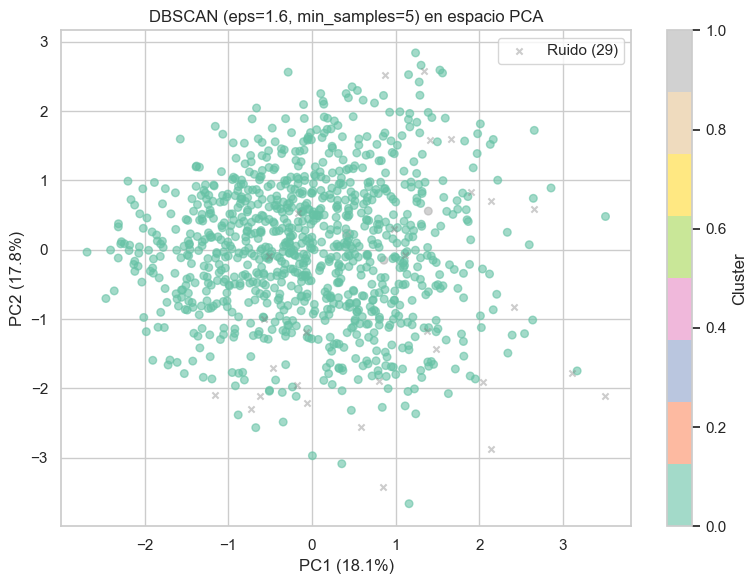

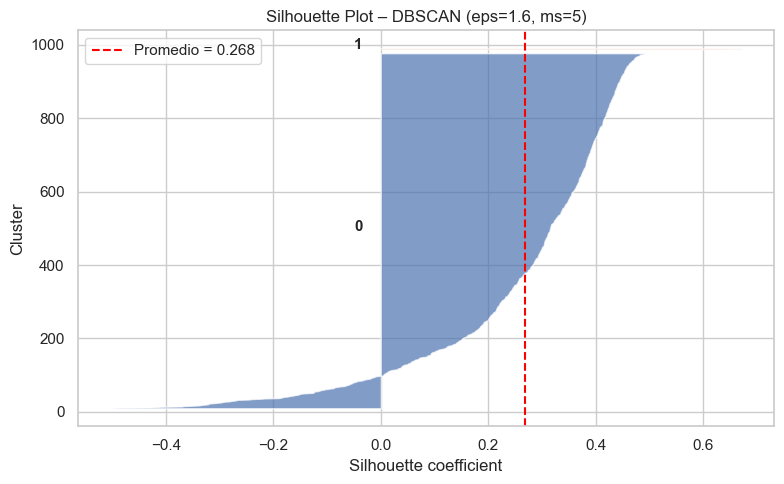

In [38]:
fig, ax = plt.subplots(figsize=FIGSIZE_SQUARE)
# -1 = ruido, se pinta en gris
colors = labels_db.copy().astype(float)
colors[labels_db == -1] = np.nan

scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=colors, cmap="Set2", alpha=0.6, s=30)
# Puntos de ruido
noise_mask = labels_db == -1
ax.scatter(X_pca[noise_mask, 0], X_pca[noise_mask, 1],
           c="grey", marker="x", alpha=0.4, s=20, label=f"Ruido ({noise_mask.sum()})")

ax.set_xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})")
ax.set_title(f"DBSCAN (eps={best_eps}, min_samples={best_min_samples}) en espacio PCA")
ax.legend()
plt.colorbar(scatter, ax=ax, label="Cluster")
plt.tight_layout()
plt.show()

if res_db["n_clusters"] >= 2:
    plot_silhouette(X_scaled.values, labels_db,
                    f"Silhouette Plot – DBSCAN (eps={best_eps}, ms={best_min_samples})")

In [39]:
comparison_df = pd.DataFrame([res_km, res_agg, res_db])
comparison_df = comparison_df.sort_values("silhouette", ascending=False)
display(comparison_df)

,method,n_clusters,n_noise,silhouette
2,"DBSCAN (eps=1.6, ms=5)",2,29,0.2677
0,K-Means (k=7),7,0,0.1745
1,Aglomerativo (k=4),4,0,0.1391


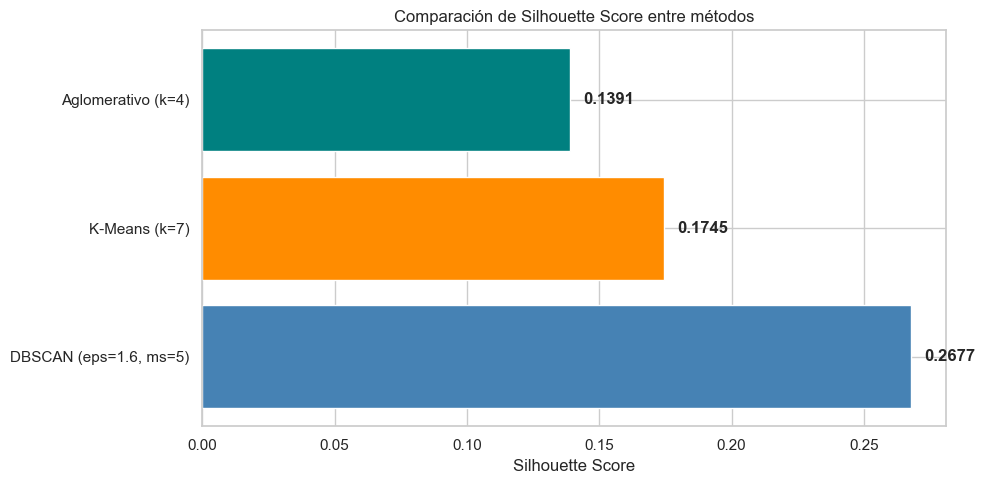

In [40]:
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(comparison_df["method"], comparison_df["silhouette"],
               color=["steelblue", "darkorange", "teal"], edgecolor="white")
ax.set_xlabel("Silhouette Score")
ax.set_title("Comparación de Silhouette Score entre métodos")
for bar, val in zip(bars, comparison_df["silhouette"]):
    if not np.isnan(val):
        ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
                f"{val:.4f}", va="center", fontweight="bold")
plt.tight_layout()
plt.show()

In [41]:
best_method = comparison_df.iloc[0]["method"]
print(f"\nMejor método por Silhouette: {best_method}")

# Asignar las etiquetas del mejor método
if "K-Means" in best_method:
    best_labels = labels_km
elif "Aglomerativo" in best_method:
    best_labels = labels_agg
else:
    best_labels = labels_db

print(f"Distribución de clusters: {pd.Series(best_labels).value_counts().sort_index().to_dict()}")


Mejor método por Silhouette: DBSCAN (eps=1.6, ms=5)
Distribución de clusters: {-1: 29, 0: 968, 1: 3}


In [42]:
df_segmented = X.copy()
df_segmented["Segment"] = best_labels
df_segmented["preferred_category"] = meta["preferred_category"].values
df_segmented["gender"] = meta["gender"].values

# Excluir ruido si aplica
df_segmented = df_segmented[df_segmented["Segment"] != -1].copy()

print(f"Registros por segmento:")
display(df_segmented["Segment"].value_counts().sort_index().to_frame("count"))

Registros por segmento:


,count
Segment,
0,968
1,3


In [43]:
segment_profile = df_segmented.groupby("preferred_category")[COLUMNASCOMP].mean().round(0)
print("\nGasto medio por segmento (escala original):")
display(segment_profile)


Gasto medio por segmento (escala original):


,age,income,spending_score,membership_years,purchase_frequency,last_purchase_amount
preferred_category,,,,,,
Clothing,45.0,89445.0,53.0,6.0,26.0,502.0
Electronics,43.0,89557.0,51.0,6.0,27.0,494.0
Groceries,44.0,88573.0,53.0,5.0,28.0,496.0
Home & Garden,43.0,89053.0,51.0,5.0,27.0,513.0
Sports,44.0,87951.0,52.0,6.0,27.0,485.0
